## Imports

In [86]:
import os
from datetime import datetime

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
from collections import Counter
import random

In [5]:
import torch
from torch import optim
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import LBFGS

In [6]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms

In [31]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc, brier_score_loss
from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve

In [8]:
import warnings
warnings.filterwarnings("ignore")

## Configs

### Dataset Used + Model Save Location

In [98]:
model_name = "mendeley_2"

In [99]:
if model_name == "main":
    data_dir = "../Datasets/main/"
    folder_name = "Main"
elif model_name == "mendeley_1":
    data_dir = "../Datasets/mendeley_1/"
    folder_name = "Mendeley_1"
elif model_name == "mendeley_2":
    data_dir = "../Datasets/mendeley_2/"
    folder_name = "Mendeley_2"

In [100]:
print(os.path.exists(data_dir))

True


### Print Options

In [54]:
np.set_printoptions(precision=3, suppress=True, linewidth=120)

### cuda Check

In [9]:
print("PyTorch version:", torch.__version__)
cudaAvailable = torch.cuda.is_available()
print("CUDA available:", cudaAvailable)
if cudaAvailable:
    print("GPU name:", torch.cuda.get_device_name(0))
    print("CUDA version (PyTorch):", torch.version.cuda)
    print("cuDNN version:", torch.backends.cudnn.version())

PyTorch version: 2.8.0+cu126
CUDA available: True
GPU name: NVIDIA GeForce RTX 3050 6GB Laptop GPU
CUDA version (PyTorch): 12.6
cuDNN version: 91002


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
device

device(type='cuda')

### Data

In [ ]:
batch_size = 16
seq_len = 3    
train_split = 0.8    

### Image Size

In [85]:
# img_size = 128
img_size = 224

### ProgNet Paramaters

In [15]:
feature_dim = 512
hidden_dim = 256
num_layers = 2
dropout = 0.3

### Training Parameters

In [16]:
epochs = 20
learning_rate = 0.001
weight_decay = 1e-4
scheduler_type = "cosine"
label_smoothing = 0.05

### Saving the Model

In [82]:
seed = 42
torch.manual_seed(seed)
random.seed(seed)

In [ ]:
save_dir = os.path.join("..", f"Saved_Models\{folder_name}")
os.makedirs(save_dir, exist_ok=True)
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M")

save_path = os.path.join(save_dir, f"{model_name}_{timestamp}.pth")        

In [97]:
print(f"Model will be saved to: {save_path}")

Model will be saved to: ..\Saved_Models\Mendeley_2\mendeley_2_2025-10-12_15-53.pth


### Transform

In [19]:
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

### Calibration Curve Parameters

In [20]:
num_bins = 5

### Saving Results

In [113]:
res_dir = os.path.join("..", "Results", folder_name)
os.makedirs(res_dir, exist_ok=True)

print(res_dir)
    

..\Results\Mendeley_2


In [114]:
results = {
    "Accuracy": "1_Accuracy",
    "Confusion Matrix": "2_Confusion_Matrix",
    "Classification Report": "3_Classification_Report",
    "Accuracy Curve": "4_Accuracy_Curve",
    "One vs All ROC Curve": "5_One_vs_All_ROC_Curve",
    "Calibration Curve": "6_Calibration_Curve",
    "Brier Scores": "7_Brier_Score"
}

#### Text Results

In [117]:
def save_text_result(result_text, result_name):
    file_path = os.path.join(res_dir, f"{results[result_name]}.txt")
    with open(file_path, "w") as f:
        f.write(result_text)
    print(f"[INFO] {result_name} saved to {file_path}")

#### Graph Results


In [124]:
def save_plot(fig, plot_name):
    file_path = os.path.join(res_dir, f"{results[plot_name]}.png")
    fig.savefig(file_path, bbox_inches='tight')
    plt.close(fig)
    print(f"[INFO] {plot_name} saved to {file_path}")

## Loading Image Data

### Sequential Wrapper of Dataset

In [21]:
class SequenceDataset(Dataset):
    def __init__(self, root, transform, seq_len=3):
        self.dataset = datasets.ImageFolder(root=root, transform=transform)
        self.classes = self.dataset.classes
        self.seq_len = seq_len
        self.class_to_idx = self.dataset.class_to_idx

        self.class_to_images = {}
        for idx, (path, label) in enumerate(self.dataset.samples):
            if label not in self.class_to_images:
                self.class_to_images[label] = []
            self.class_to_images[label].append(idx)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        choices = random.choices(self.class_to_images[label], k=self.seq_len-1)
        imgs = [img] + [self.dataset[i][0] for i in choices]

        imgs = torch.stack(imgs, dim=0)
        return imgs, label

### Load Data

In [65]:
dataset = SequenceDataset(root=data_dir, transform=transform, seq_len=seq_len)
class_names = dataset.classes
num_classes = len(class_names)

### Train and Test Split

In [32]:
targets = [label for _, label in dataset.dataset.samples]
sss = StratifiedShuffleSplit(n_splits=1, test_size=(1-train_split), random_state=seed)
train_idx, test_idx = next(sss.split(np.zeros(len(targets)), targets))

train_dataset = torch.utils.data.Subset(dataset, train_idx)
test_dataset = torch.utils.data.Subset(dataset, test_idx)

In [ ]:
# train_size = int(train_split * len(dataset))
# test_size = len(dataset) - train_size
# train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [33]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [34]:
print(f"Classes: {class_names}")
print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")

Classes: ['Banded Chlorosis', 'Brown Rust', 'Brown Spot', 'Dried Leaf', 'Grassy Shoot', 'Healthy Leaf', 'Pokkah Boeng', 'Sett Rot', 'Smut', 'Viral Disease', 'Yellow Leaf']
Train: 5398 | Test: 1350


In [26]:
train_labels = [dataset[i][1] for i in train_dataset.indices]
test_labels = [dataset[i][1] for i in test_dataset.indices]

train_classes = sorted(set(train_labels))
test_classes = sorted(set(test_labels))

print("Classes in Train Set:", [class_names[i] for i in train_classes])
print("Classes in Test Set:", [class_names[i] for i in test_classes])

missing_in_train = set(range(num_classes)) - set(train_classes)
missing_in_test = set(range(num_classes)) - set(test_classes)

if not missing_in_train and not missing_in_test:
    print("\nAll classes are present in both train and test sets.")
else:
    print("\nMissing classes:")
    if missing_in_train:
        print(" - In train:", [class_names[i] for i in missing_in_train])
    if missing_in_test:
        print(" - In test:", [class_names[i] for i in missing_in_test])

Classes in Train Set: ['Banded Chlorosis', 'Brown Rust', 'Brown Spot', 'Dried Leaf', 'Grassy Shoot', 'Healthy Leaf', 'Pokkah Boeng', 'Sett Rot', 'Smut', 'Viral Disease', 'Yellow Leaf']
Classes in Test Set: ['Banded Chlorosis', 'Brown Rust', 'Brown Spot', 'Dried Leaf', 'Grassy Shoot', 'Healthy Leaf', 'Pokkah Boeng', 'Sett Rot', 'Smut', 'Viral Disease', 'Yellow Leaf']

All classes are present in both train and test sets.


## Distribution of Images

### Class-Wise Distribution

In [35]:
class_counts = Counter(dataset.dataset.targets)
classes = dataset.classes

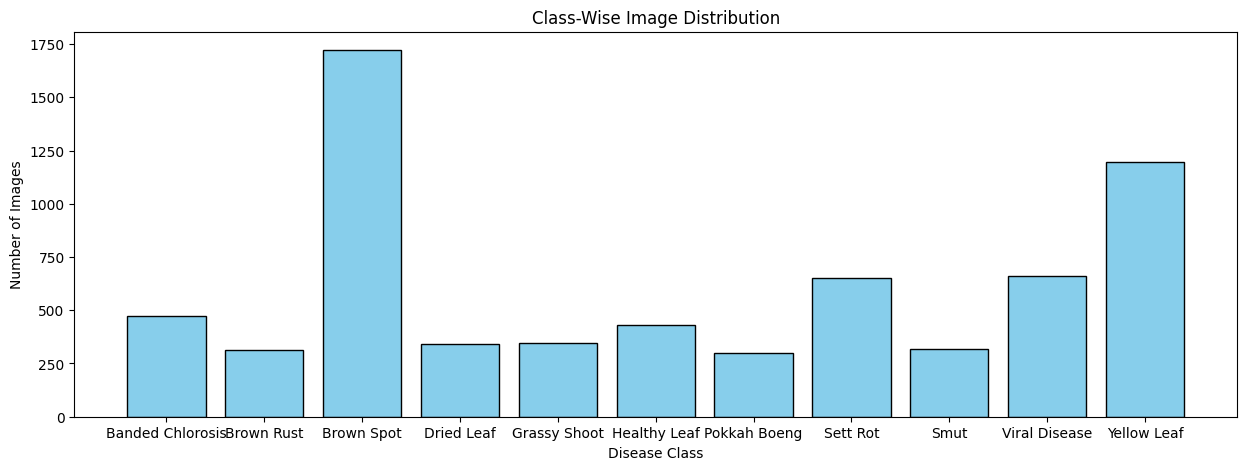

In [36]:
counts = [class_counts[i] for i in range(len(classes))]

plt.figure(figsize=(15,5))
plt.bar(classes, counts, color="skyblue", edgecolor="black")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.title("Class-Wise Image Distribution")
plt.show()

### Class-Wise Train-Test Distribution

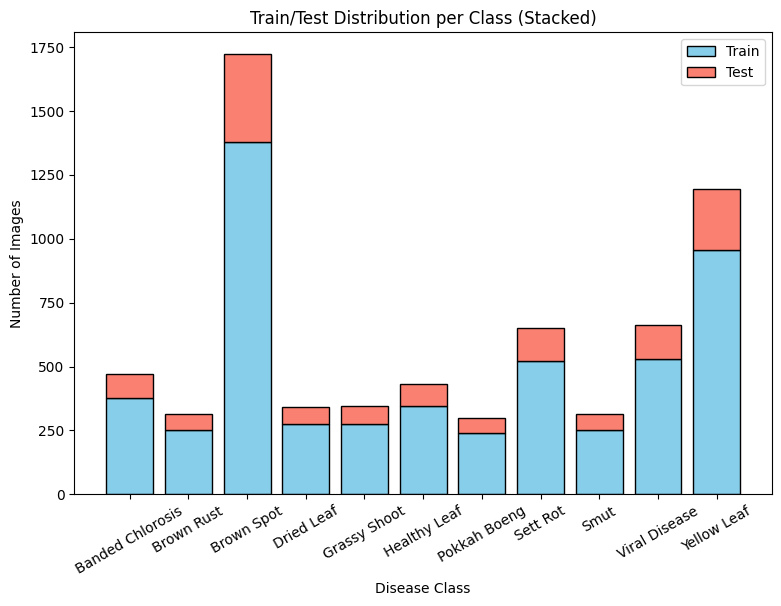

In [37]:
train_counts = Counter([dataset.dataset.targets[i] for i in train_dataset.indices])
test_counts  = Counter([dataset.dataset.targets[i] for i in test_dataset.indices])

train_vals = [train_counts[i] for i in range(len(classes))]
test_vals  = [test_counts[i] for i in range(len(classes))]

x = range(len(classes))
plt.figure(figsize=(9,6))
plt.bar(x, train_vals, label="Train", color="skyblue", edgecolor="black")
plt.bar(x, test_vals, bottom=train_vals, label="Test", color="salmon", edgecolor="black")

plt.xticks(x, classes, rotation=30)
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.title("Train/Test Distribution per Class (Stacked)")
plt.legend()
plt.show()

### Image Distribution Summary

In [38]:
for image_class, count in class_counts.items():
    print(f"{dataset.classes[image_class]}: {count}")

print(f"\nTotal images: {len(dataset)}")

Banded Chlorosis: 471
Brown Rust: 314
Brown Spot: 1722
Dried Leaf: 343
Grassy Shoot: 346
Healthy Leaf: 430
Pokkah Boeng: 297
Sett Rot: 652
Smut: 316
Viral Disease: 663
Yellow Leaf: 1194

Total images: 6748


## Model

### SymNet - CNN Symptom Feature Extractor

In [39]:
def conv_block(cin, cout, k=3, s=1, p=1):
    return nn.Sequential(
        nn.Conv2d(cin, cout, kernel_size=k, stride=s, padding=p, bias=False),
        nn.BatchNorm2d(cout),
        nn.ReLU(inplace=True),
    )

In [40]:
class SymNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 32),
            nn.MaxPool2d(2),
        )
        self.stage2 = nn.Sequential(
            conv_block(32, 64),
            conv_block(64, 64),
            nn.MaxPool2d(2),
        )
        self.stage3 = nn.Sequential(
            conv_block(64, 128),
            conv_block(128, 128),
            nn.MaxPool2d(2),
        )
        self.stage4 = nn.Sequential(
            conv_block(128, 256),
            conv_block(256, 256),
            nn.MaxPool2d(2),
        )
        self.stage5 = nn.Sequential(
            conv_block(256, 512),
            conv_block(512, 512),
            nn.AdaptiveAvgPool2d(1),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.stage5(x)
        return x.view(x.size(0), -1) 

### ProgNet - LSTM Sequence Modeler

In [41]:
class ProgNet(nn.Module):
    def __init__(self, feature_dim=feature_dim, hidden_dim=hidden_dim, num_layers=num_layers,
                 num_classes=num_classes, dropout=dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=feature_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, num_classes)
        )

    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        last_hidden = torch.cat((hn[-2], hn[-1]), dim=1)
        return self.fc(last_hidden)

### CaneSight - SymNet + ProgNet

In [42]:
class CaneSight(nn.Module):
    def __init__(self, symnet, prognet):
        super().__init__()
        self.symnet = symnet
        self.prognet = prognet

    def forward(self, x_seq):
        batch_size, seq_len, C, H, W = x_seq.size()
        features = []

        for t in range(seq_len):
            img = x_seq[:, t, :, :, :]
            feat = self.symnet(img)
            features.append(feat)

        features = torch.stack(features, dim=1)
        return self.prognet(features)

## Training

In [43]:
symnet = SymNet()
prognet = ProgNet()
model = CaneSight(symnet, prognet).to(device)

In [44]:
criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

In [45]:
if scheduler_type == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
elif scheduler_type == "step":
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
else:
    scheduler = None

### Training Function

In [46]:
def train_one_epoch(loader):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        total_correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss/total, total_correct/total

### Testing Function

In [47]:
def test(loader):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * imgs.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    return total_loss/total, total_correct/total

### Training Loop

In [48]:
best_acc = 0.0

train_acc_history = []
test_acc_history = []

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(train_loader)
    test_loss, test_acc = test(test_loader)

    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)
    
    if scheduler is not None:
        scheduler.step()

    print(f"Epoch {epoch:02d}/{epochs} | "
          f"Train Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}")

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), save_path)

print(f"\nTraining Complete.\nBest Test Accuracy: {best_acc:.4f}")

Epoch 01/20 | Train Loss: 1.2816, Accuracy: 0.5900 | Test Loss: 0.8009, Accuracy: 0.7941
Epoch 02/20 | Train Loss: 0.8474, Accuracy: 0.7870 | Test Loss: 0.8112, Accuracy: 0.7948
Epoch 03/20 | Train Loss: 0.7174, Accuracy: 0.8318 | Test Loss: 0.6440, Accuracy: 0.8459
Epoch 04/20 | Train Loss: 0.6404, Accuracy: 0.8649 | Test Loss: 0.5833, Accuracy: 0.8889
Epoch 05/20 | Train Loss: 0.6079, Accuracy: 0.8774 | Test Loss: 0.5730, Accuracy: 0.8926
Epoch 06/20 | Train Loss: 0.5664, Accuracy: 0.8883 | Test Loss: 0.4527, Accuracy: 0.9326
Epoch 07/20 | Train Loss: 0.5109, Accuracy: 0.9161 | Test Loss: 0.4885, Accuracy: 0.9333
Epoch 08/20 | Train Loss: 0.4867, Accuracy: 0.9263 | Test Loss: 0.3823, Accuracy: 0.9696
Epoch 09/20 | Train Loss: 0.4623, Accuracy: 0.9350 | Test Loss: 0.4288, Accuracy: 0.9570
Epoch 10/20 | Train Loss: 0.4457, Accuracy: 0.9474 | Test Loss: 0.3934, Accuracy: 0.9689
Epoch 11/20 | Train Loss: 0.4302, Accuracy: 0.9485 | Test Loss: 0.3708, Accuracy: 0.9719
Epoch 12/20 | Train L

In [115]:
accuracy = f"Accuracy: {best_acc*100:.2f}%"
print(accuracy)

Accuracy: 99.85%


In [119]:
save_text_result(accuracy, "Accuracy")

[INFO] Accuracy saved to ..\Results\Mendeley_2\1_Accuracy.txt


## Result Analysis

### Load Best Model

In [50]:
model.load_state_dict(torch.load(save_path))
model.eval()

CaneSight(
  (symnet): SymNet(
    (stem): Sequential(
      (0): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (1): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (stage2): Sequential(
      (0): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (1): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

### Labels, Predictions, Probabilities

In [51]:
all_labels = []
all_preds = []
all_probs = []

logits_list = []
labels_list = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1)
        probs = torch.softmax(outputs, dim=1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        logits_list.append(outputs)
        labels_list.append(labels)

In [52]:
all_labels_np = np.array(all_labels)
all_preds_np = np.array(all_preds)
all_probs_np = np.array(all_probs)

In [55]:
all_probs_np

array([[0.125, 0.734, 0.017, ..., 0.01 , 0.048, 0.008],
       [0.027, 0.949, 0.004, ..., 0.003, 0.002, 0.002],
       [0.001, 0.001, 0.001, ..., 0.991, 0.001, 0.001],
       ...,
       [0.003, 0.003, 0.003, ..., 0.002, 0.002, 0.002],
       [0.004, 0.003, 0.003, ..., 0.017, 0.002, 0.003],
       [0.004, 0.003, 0.004, ..., 0.004, 0.004, 0.966]], shape=(1350, 11), dtype=float32)

### Confusion Matrix

Text(0.5, 1.0, 'Confusion Matrix')

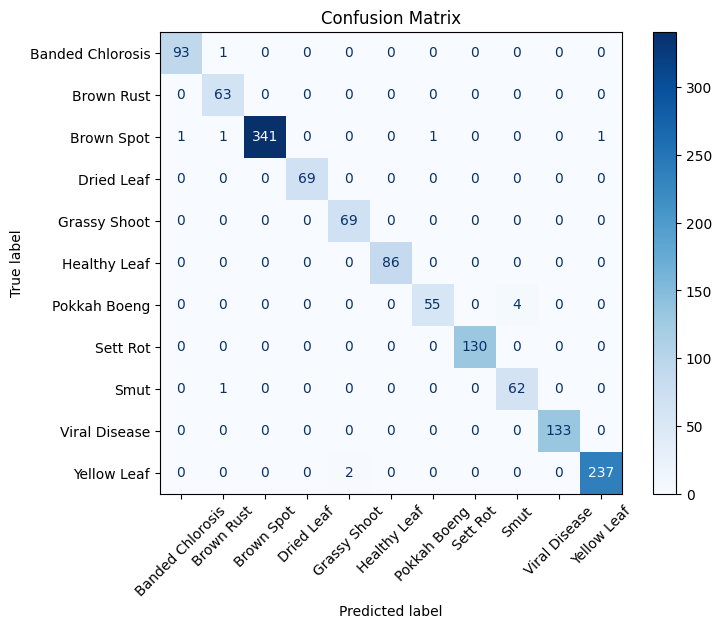

In [126]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix")

In [127]:
save_plot(fig, "Confusion Matrix")

[INFO] Confusion Matrix saved to ..\Results\Mendeley_2\2_Confusion_Matrix.png


### Classification Report

In [128]:
cr = classification_report(all_labels, all_preds, target_names=class_names)
print(cr)

                  precision    recall  f1-score   support

Banded Chlorosis       0.99      0.99      0.99        94
      Brown Rust       0.95      1.00      0.98        63
      Brown Spot       1.00      0.99      0.99       345
      Dried Leaf       1.00      1.00      1.00        69
    Grassy Shoot       0.97      1.00      0.99        69
    Healthy Leaf       1.00      1.00      1.00        86
    Pokkah Boeng       0.98      0.93      0.96        59
        Sett Rot       1.00      1.00      1.00       130
            Smut       0.94      0.98      0.96        63
   Viral Disease       1.00      1.00      1.00       133
     Yellow Leaf       1.00      0.99      0.99       239

        accuracy                           0.99      1350
       macro avg       0.98      0.99      0.99      1350
    weighted avg       0.99      0.99      0.99      1350



In [129]:
save_text_result(cr, "Classification Report")

[INFO] Classification Report saved to ..\Results\Mendeley_2\3_Classification_Report.txt


### Per-Class Accuracy

In [58]:
class_accuracy = cm.diagonal() / cm.sum(axis=1)

for i, cls in enumerate(class_names):
    print(f"{cls}: {class_accuracy[i]*100:.2f}%")

Banded Chlorosis: 98.94%
Brown Rust: 100.00%
Brown Spot: 98.84%
Dried Leaf: 100.00%
Grassy Shoot: 100.00%
Healthy Leaf: 100.00%
Pokkah Boeng: 93.22%
Sett Rot: 100.00%
Smut: 98.41%
Viral Disease: 100.00%
Yellow Leaf: 99.16%


### Accuracy Curves

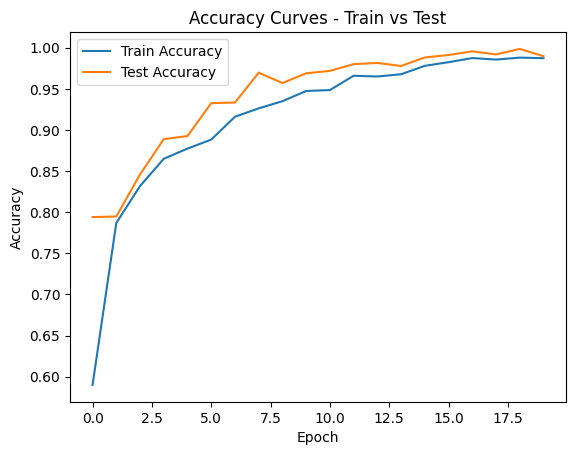

In [132]:
fig, ax = plt.subplots()
ax.plot(train_acc_history, label="Train Accuracy")
ax.plot(test_acc_history, label="Test Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Curves - Train vs Test")
ax.legend()

In [133]:
save_plot(fig, "Accuracy Curve")

[INFO] Accuracy Curve saved to ..\Results\Mendeley_2\4_Accuracy_Curve.png


### One vs All ROC Curves

The ROC curve shows the trade-off between sensitivity (or TPR) and specificity (1 – FPR). Classifiers that give curves closer to the top-left corner indicate a better performance. As a baseline, a random classifier is expected to give points lying along the diagonal (FPR = TPR). The closer the curve comes to the 45-degree diagonal of the ROC space, the less accurate the test.

Note that the ROC does not depend on the class distribution. This makes it useful for evaluating classifiers predicting rare events such as diseases or disasters. In contrast, evaluating performance using accuracy (TP + TN)/(TP + TN + FN + FP) would favor classifiers that always predict a negative outcome for rare events.

1.  Locate the Curve – A curve closer to the top-left corner indicates a more accurate classifier.
2.  Compare to Diagonal – The diagonal line (FPR = TPR) represents random guessing; curves near it have poor predictive power.
3.  Check the Trade-off – Moving along the curve shows how sensitivity (true positive rate) changes against specificity (1 – false positive rate).
4.  Consider Class Imbalance – ROC curves work well even when your dataset has rare events, unlike accuracy, which can be misleading in these cases.

In [134]:
y_bin = label_binarize(all_labels_np, classes=list(range(num_classes)))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], all_probs_np[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

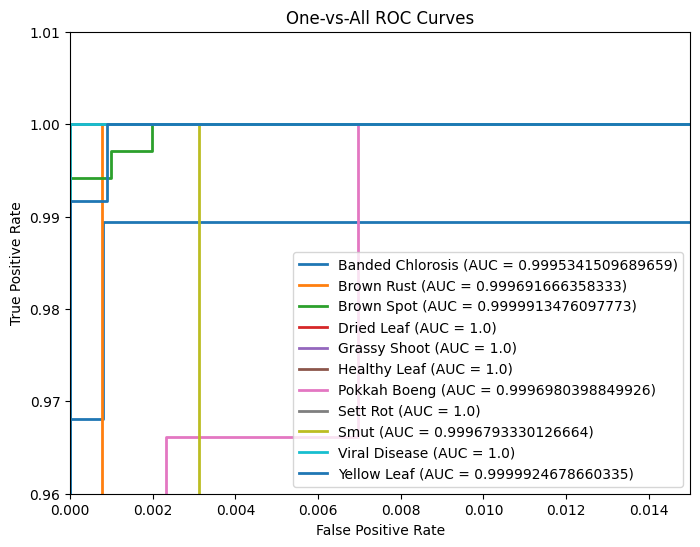

In [135]:
fig, ax = plt.subplots(figsize=(8, 6))
for i, cls in enumerate(class_names):
    ax.plot(fpr[i], tpr[i], lw=2,
             label=f"{cls} (AUC = {roc_auc[i]})")

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlim([0.0, 0.015])
ax.set_ylim([0.96, 1.01])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("One-vs-All ROC Curves")
ax.legend(loc="lower right")

In [136]:
save_plot(fig, "One vs All ROC Curve")

[INFO] One vs All ROC Curve saved to ..\Results\Mendeley_2\5_One_vs_All_ROC_Curve.png


### Calibration Curve

- A calibration curve is a line plot of the relative frequency of what was observed (y-axis) versus the predicted probability frequency (x-axis).
- They are used to evaluate how calibrated a classifier is i.e., how the probabilities of predicting each class label differ. 
- The x-axis represents the average predicted probability in each bin. 
- The y-axis is the ratio of positives (the proportion of positive predictions). 
- The curve of the ideal calibrated model is a linear straight line from (0, 0) moving linearly. 

In [61]:
all_labels_np.shape

(1350,)

In [62]:
all_probs_np.shape

(1350, 11)

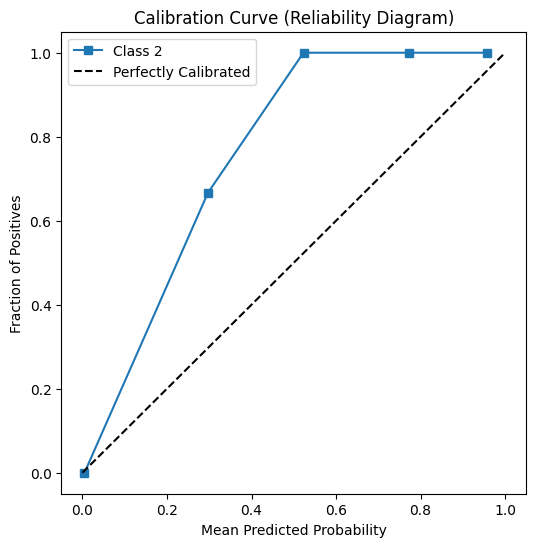

In [63]:
class_id = 2
probs_class = all_probs_np[:, class_id]
labels_class = (all_labels_np == class_id).astype(int)

fraction_of_positives, mean_predicted_value = calibration_curve(
    labels_class, probs_class, n_bins=num_bins
)

plt.figure(figsize=(6,6))
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label=f"Class {class_id}")
plt.plot([0,1], [0,1], "k--", label="Perfectly Calibrated")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve (Reliability Diagram)")
plt.legend()
plt.show()


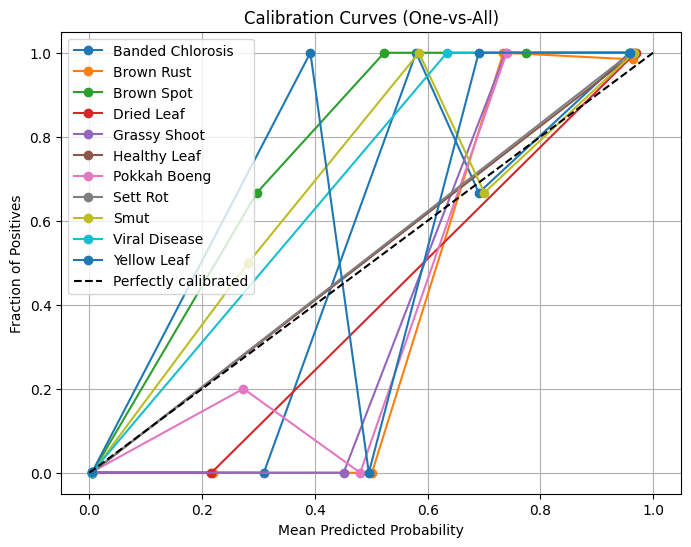

In [66]:
plt.figure(figsize=(8, 6))

for i in range(num_classes):
    y_true_i = (all_labels_np == i).astype(int)
    y_prob_i = all_probs_np[:, i]

    prob_true, prob_pred = calibration_curve(y_true_i, y_prob_i, n_bins=num_bins)

    plt.plot(prob_pred, prob_true, marker='o', label=f"{class_names[i]}")

plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curves (One-vs-All)")
plt.legend(loc="upper left")
plt.grid(True)
plt.show()

## Temperature Scaling

### Common Temperature Scaler

In [67]:
class TempScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.T = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, logits):
        return logits / self.T.to(logits.device)


### Configs

In [68]:
logits = torch.cat(logits_list, dim=0)
labels = torch.cat(labels_list, dim=0) 

In [69]:
scaler = TempScaler()
temp_criterion = nn.CrossEntropyLoss()
temp_optimizer = LBFGS([scaler.T], lr=0.01, max_iter=50)

In [70]:
def eval():
    temp_optimizer.zero_grad()
    loss = temp_criterion(scaler(logits), labels)
    loss.backward()
    return loss

### Learning the Temperature

In [71]:
optimizer.step(eval)
print(f"Learned Temperature: {scaler.T.item():.3f}")

Learned Temperature: 1.500


### Scaling Based on Learned Temperature

In [72]:
scaled_probs = torch.softmax(scaler(logits), dim=1).detach().cpu().numpy()

### Calibration Curve with Scaled Probabilities

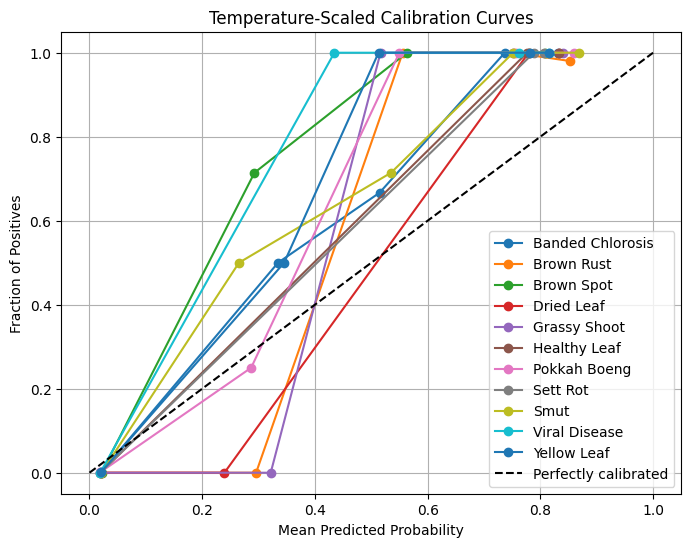

In [73]:
plt.figure(figsize=(8,6))

for i in range(num_classes):
    y_true_i = (all_labels_np == i).astype(int)
    y_prob_i = scaled_probs[:, i]
    prob_true, prob_pred = calibration_curve(y_true_i, y_prob_i, n_bins=num_bins)
    plt.plot(prob_pred, prob_true, marker='o', label=f"{class_names[i]}")

plt.plot([0,1], [0,1], 'k--', label='Perfectly calibrated')
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Temperature-Scaled Calibration Curves")
plt.legend()
plt.grid(True)
plt.show()

## Per-Class Temperature Scaling

### Class-Wise Temperature Scaler

In [74]:
class ClasswiseTempScaler(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.T = nn.Parameter(torch.ones(num_classes) * 1.5)

    def forward(self, logits):
        return logits / self.T.unsqueeze(0).to(logits.device)

### Configs

In [75]:
scaler = ClasswiseTempScaler(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = LBFGS([scaler.T], lr=0.01, max_iter=50)

In [76]:
def closure():
    optimizer.zero_grad()
    loss = criterion(scaler(logits), labels)
    loss.backward()
    return loss

### Learning the Temperature

In [77]:
optimizer.step(closure)
print("Learned class-wise temperatures:", scaler.T.detach().cpu().numpy())

Learned class-wise temperatures: [1.125 1.244 1.064 1.181 1.156 1.166 1.124 1.128 1.15  1.107 1.092]


### Scaling

In [78]:
scaled_probs = torch.softmax(scaler(logits), dim=1).detach().cpu().numpy()

In [79]:
scaled_probs

array([[0.168, 0.598, 0.028, ..., 0.018, 0.073, 0.014],
       [0.057, 0.875, 0.011, ..., 0.009, 0.005, 0.004],
       [0.003, 0.002, 0.001, ..., 0.977, 0.002, 0.002],
       ...,
       [0.007, 0.006, 0.007, ..., 0.005, 0.005, 0.005],
       [0.008, 0.006, 0.006, ..., 0.031, 0.005, 0.006],
       [0.006, 0.005, 0.006, ..., 0.006, 0.007, 0.945]], shape=(1350, 11), dtype=float32)

### Calibration Curve with Class-Wise Scaling

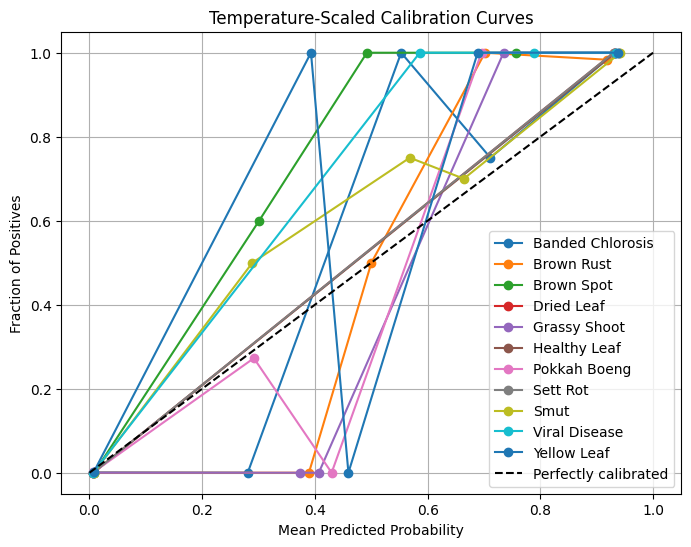

In [137]:
fig, ax = plt.subplots(figsize=(8,6))

for i in range(num_classes):
    y_true_i = (all_labels_np == i).astype(int)
    y_prob_i = scaled_probs[:, i]
    prob_true, prob_pred = calibration_curve(y_true_i, y_prob_i, n_bins=num_bins)
    ax.plot(prob_pred, prob_true, marker='o', label=f"{class_names[i]}")

ax.plot([0,1], [0,1], 'k--', label='Perfectly calibrated')
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.set_title("Temperature-Scaled Calibration Curves")
ax.legend()
ax.grid(True)

In [138]:
save_plot(fig, "Calibration Curve")

[INFO] Calibration Curve saved to ..\Results\Mendeley_2\6_Calibration_Curve.png


## Brier Score

- The Brier score is a strictly proper scoring rule that measures the accuracy of probabilistic predictions.  
- For unidimensional predictions, it is strictly equivalent to the mean squared error as applied to predicted probabilities.  
- The Brier score can be thought of as a cost function. More precisely, across all items *i* ∈ {1...N} in a set of N predictions, the Brier score measures the mean squared difference between:  
  - The predicted probability assigned to the possible outcomes for item *i*  
  - The actual outcome *o(i)*  

In [ ]:
brier_scores = []
scores = ""

scores += f"{'Class':<20} {'Brier Score':>12}\n"
scores += "-" * 32 + "\n"

for i, cls in enumerate(class_names):
    score = brier_score_loss(y_bin[:, i], scaled_probs[:, i])
    brier_scores.append(score)
    scores += f"{cls:<20} {score:>12.4f}\n"

overall_brier = np.mean(brier_scores)
scores += "-" * 32
scores += f"\n{'Overall':<20} {overall_brier:>12.4f}"

print(scores)

Class                 Brier Score
--------------------------------
Banded Chlorosis           0.0020
Brown Rust                 0.0016
Brown Spot                 0.0029
Dried Leaf                 0.0004
Grassy Shoot               0.0007
Healthy Leaf               0.0004
Pokkah Boeng               0.0027
Sett Rot                   0.0006
Smut                       0.0029
Viral Disease              0.0007
Yellow Leaf                0.0021
--------------------------------
Overall                    0.0015
